Actividad #1 - Data Science Salaries

# 0 Libraries & Data Load

In [27]:
# !pip install mlcroissant
import mlcroissant as mlc

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance

import shap

# Configuración visual
sns.set_theme(style="whitegrid")

# Desactivar la notación científica en Pandas (muestra hasta 2 decimales normales)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


In [8]:


# Fetch the Croissant JSON-LD
croissant_dataset = mlc.Dataset('https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023/croissant/download')

# Check what record sets are in the dataset
record_sets = croissant_dataset.metadata.record_sets
print(record_sets)

# Fetch the records and put them in a DataFrame
data = pd.DataFrame(croissant_dataset.records(record_set=record_sets[0].uuid))# Esto elimina el prefijo incluyendo la barra "/" o "\" en cualquier dirección
data.columns = data.columns.str.replace(r'^/?ds_salaries\.csv/?', '', regex=True)


# Seleccionamos todas las columnas que son de tipo texto (object)
columnas_texto = data.select_dtypes(include=['object']).columns

# Recorremos esas columnas y decodificamos los bytes a texto normal (utf-8)
for col in columnas_texto:
    data[col] = data[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

# Volvemos a ver cómo quedó
data.head()


print(data.info())
display(data.head())



  -  [Metadata(Data Science Salaries 2023 💸)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.


[RecordSet(uuid="ds_salaries.csv")]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB
None


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


# 1 Exploratory Data Analysis (EDA)
**Objetivo principal:** Predecir la variable objetivo (target) `salary_in_usd`

In [5]:
# Verificamos si hay nulos en nuestro target (crucial para predicción)
nulos_target = data['salary_in_usd'].isnull().sum()
print(f"Valores nulos en el target 'salary_in_usd': {nulos_target}")

print("\n--- ESTADÍSTICAS DESCRIPTIVAS DEL TARGET ---")
display(data[['salary_in_usd']].describe())

Valores nulos en el target 'salary_in_usd': 0

--- ESTADÍSTICAS DESCRIPTIVAS DEL TARGET ---


,salary_in_usd
count,3755.00
mean,137570.39
std,63055.63
min,5132.00
25%,95000.00
50%,135000.00
75%,175000.00
max,450000.00


## 1.1 Análisis de la Variable Objetivo: `salary_in_usd`


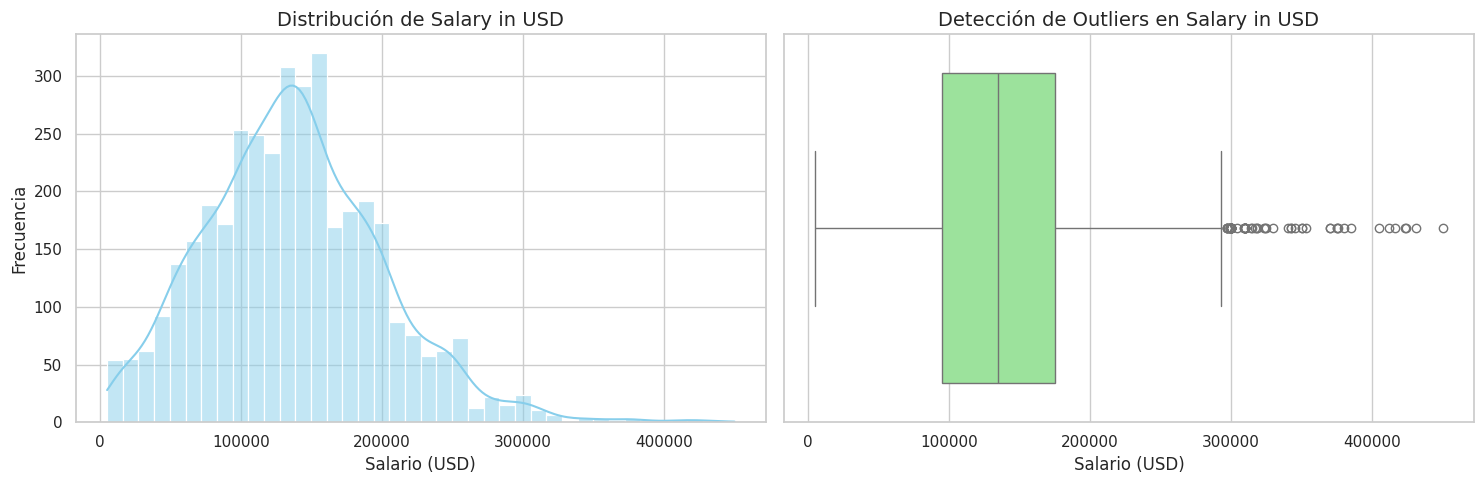

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma para ver la distribución
sns.histplot(data['salary_in_usd'], bins=40, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Salary in USD', fontsize=14)
axes[0].set_xlabel('Salario (USD)')
axes[0].set_ylabel('Frecuencia')

# Boxplot para identificar outliers
sns.boxplot(x=data['salary_in_usd'], color='lightgreen', ax=axes[1])
axes[1].set_title('Detección de Outliers en Salary in USD', fontsize=14)
axes[1].set_xlabel('Salario (USD)')

plt.tight_layout()
plt.show()

## 1.2 Salario Promedio por Rol (`job_title`)

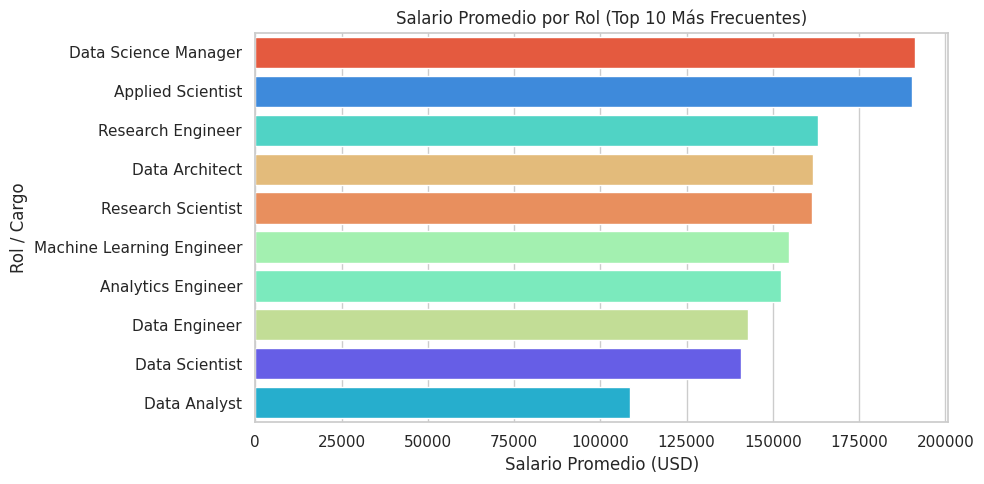

In [15]:
# Nos enfocamos en los 10 roles que más se repiten en el dataset para evitar ruido
top_10_roles = data['job_title'].value_counts().head(10).index
data_top_roles = data[data['job_title'].isin(top_10_roles)]

plt.figure(figsize=(10, 5))
# Calculamos y graficamos el salario promedio, ordenado de mayor a menor
sns.barplot(
    data=data_top_roles,
    y='job_title',
    x='salary_in_usd',
    errorbar=None,
    order=data_top_roles.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).index,
    palette='rainbow',
    hue='job_title',   # <-- Agregamos hue
    legend=False       # <-- Desactivamos la leyenda para que no sea redundante
)

plt.title('Salario Promedio por Rol (Top 10 Más Frecuentes)')
plt.xlabel('Salario Promedio (USD)')
plt.ylabel('Rol / Cargo')
plt.tight_layout()
plt.show()

## 1.3 Evolución del Salario por Año (`work_year`)

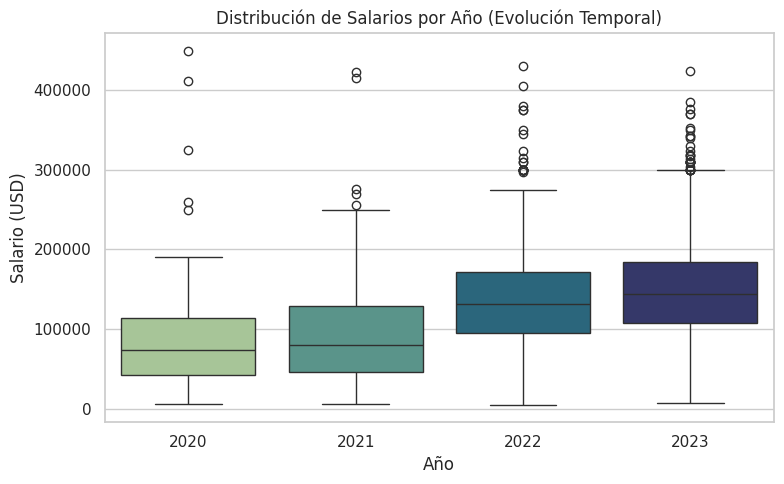

Salario promedio anual:
work_year
2020    92302.63
2021    94087.21
2022   133338.62
2023   149045.54
Name: salary_in_usd, dtype: float64


In [17]:
plt.figure(figsize=(8, 5))
# Usamos un gráfico de caja (boxplot) para ver cómo se distribuyen los sueldos en cada año
sns.boxplot(
    data=data, 
    x='work_year', 
    y='salary_in_usd', 
    palette='crest',
    hue='work_year',  # <-- Asignamos la variable x al hue
    legend=False      # <-- Desactivamos la leyenda
)
plt.title('Distribución de Salarios por Año (Evolución Temporal)')
plt.xlabel('Año')
plt.ylabel('Salario (USD)')
plt.tight_layout()
plt.show()

# Imprimimos el salario promedio exacto por año para mayor claridad
print("Salario promedio anual:")
print(data.groupby('work_year')['salary_in_usd'].mean().round(2))


# 2 Entrenamiento de Modelo (Con todas las variables)
Entrenaremos un modelo Random Forest utilizando **todas las variables disponibles**

In [19]:
# 1. Separar features y target usando TODAS las variables
X_todas = data.drop(columns=['salary_in_usd'])
y = data['salary_in_usd']

# 2. Preprocesador
cat_cols = X_todas.select_dtypes(include=['object']).columns
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
    remainder='passthrough'
)

# 3. Pipeline y entrenamiento
model_todas = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_todas, y, test_size=0.2, random_state=42)
model_todas.fit(X_train_t, y_train_t)

print(f"R² del modelo con todas las variables: {r2_score(y_test_t, model_todas.predict(X_test_t)):.4f}")

R² del modelo con todas las variables: 0.9832


## 2.1 Diagnóstico Global (PFI) y Detección de Leakage
Analizamos la importancia de las variables

,Variable,Importancia
4,salary,1.93
5,salary_currency,0.44
6,employee_residence,0.00
8,company_location,0.00
3,job_title,0.00
9,company_size,0.00
0,work_year,0.00
2,employment_type,0.00
1,experience_level,-0.00
7,remote_ratio,-0.00


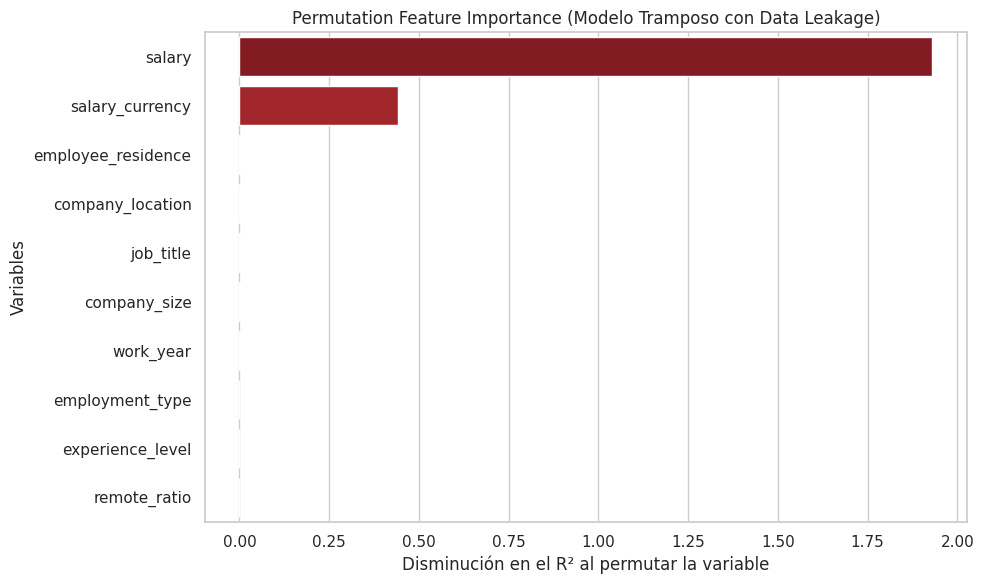

In [22]:
pfi_result = permutation_importance(model_todas, X_test_t, y_test_t, n_repeats=5, random_state=42, n_jobs=-1)

pfi_df = pd.DataFrame({
    'Variable': X_test_t.columns,
    'Importancia': pfi_result.importances_mean
}).sort_values(by='Importancia', ascending=False)

display(pfi_df)

# Graficar el PFI
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=pfi_df, 
    palette='Reds_r',
    hue='Variable', # <-- Asignamos la variable y al hue
    legend=False    # <-- Desactivamos la leyenda
)
plt.title('Permutation Feature Importance (Modelo Tramposo con Data Leakage)')
plt.xlabel('Disminución en el R² al permutar la variable')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()


**¡Data Leakage detectado!** El modelo tiene un desempeño casi perfecto y el PFI muestra que la variable `salary` absorbe casi toda la importancia. Esto **no es razonable**, ya que `salary` es el mismo sueldo que el target pero en otra moneda. Le dimos al modelo la respuesta correcta en los datos de entrada, produciendo información duplicada y fuga de información (Leakage).

**Acción correctiva:** Eliminaremos las variables redundantes (`salary` y `salary_currency`) para tener un modelo válido y reentrenaremos.

# 3 Nuevo Modelo (Fix del Data Lekage)


In [23]:
# 1. Eliminamos el leakage
X_clean = data.drop(columns=['salary', 'salary_currency', 'salary_in_usd'])

cat_cols_c = X_clean.select_dtypes(include=['object']).columns
preprocessor_c = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_c)],
    remainder='passthrough'
)

model_clean = Pipeline([
    ('preprocessor', preprocessor_c),
    ('regressor', RandomForestRegressor(random_state=42))
])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y, test_size=0.2, random_state=42)
model_clean.fit(X_train_c, y_train_c)

print(f"R² del modelo corregido (Realista): {r2_score(y_test_c, model_clean.predict(X_test_c)):.4f}")

R² del modelo corregido (Realista): 0.3997


## 3.1 PFI del Modelo Limpio
Descubrir cuáles son las **verdaderas** variables que más impactan el sueldo de un profesional de datos en el mundo real.

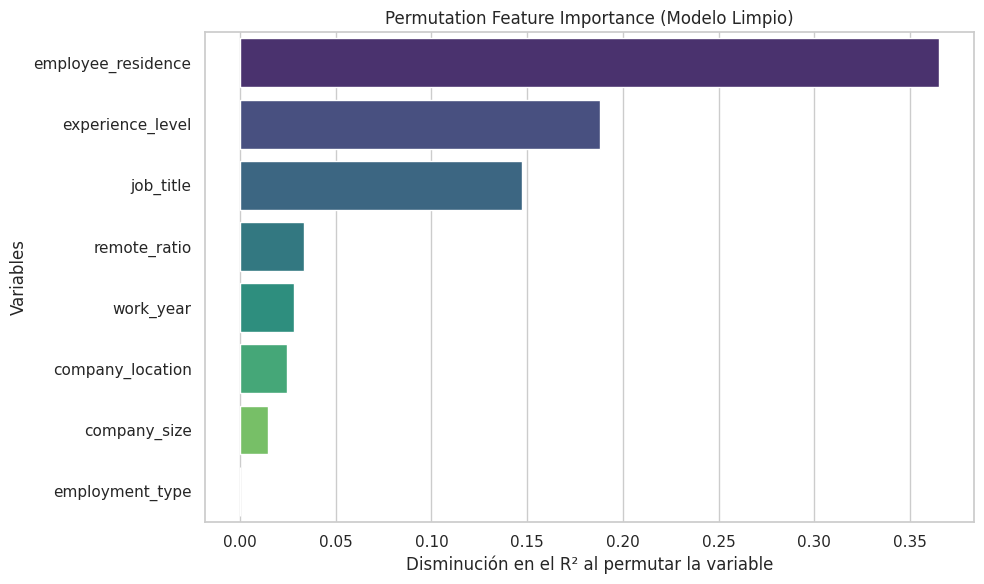

In [26]:
pfi_result_clean = permutation_importance(model_clean, X_test_c, y_test_c, n_repeats=5, random_state=42, n_jobs=-1)

pfi_clean_df = pd.DataFrame({
    'Variable': X_test_c.columns,
    'Importancia': pfi_result_clean.importances_mean
}).sort_values(by='Importancia', ascending=False)

# Graficar el nuevo PFI
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=pfi_clean_df, 
    palette='viridis',
    hue='Variable',  # <-- Asignamos la variable y al hue
    legend=False     # <-- Desactivamos la leyenda
)
plt.title('Permutation Feature Importance (Modelo Limpio)')
plt.xlabel('Disminución en el R² al permutar la variable')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()


**Conclusión del Modelo Realista (Top 3 Variables):**
Al observar el gráfico del modelo limpio, vemos una distribución de importancia lógica y esperable. Las 3 variables que más gobiernan el sueldo son:
1. **`employee_residence`**: Es el factor más determinante con diferencia. El país desde donde trabaja el empleado dicta el piso y el techo salarial, marcando una enorme brecha entre, por ejemplo, los salarios en EE.UU. frente al resto del mundo.
2. **`experience_level`**: El nivel de experiencia (*seniority*) es el segundo factor crítico. Escalar de un nivel Junior o Semi-Senior a uno Senior o Ejecutivo tiene un impacto directo y enorme en la compensación.
3. **`job_title`**: El rol específico también pesa fuertemente, separando la escala salarial de posiciones directivas (como *Data Science Manager* o *Director*) frente a roles más tradicionales.

# 4 Diagnóstico Local (SHAP)
Ya solucionado el leakage, analizamos por qué el modelo válido tomó sus decisiones para los casos específicos **1288** y **3713**.

In [28]:
casos_indices = [1288, 3713]
casos_x = X_test_c.loc[casos_indices]

rf_clean = model_clean.named_steps['regressor']
prep_clean = model_clean.named_steps['preprocessor']

datos_transformados = prep_clean.transform(casos_x)
if hasattr(datos_transformados, 'toarray'):
    datos_transformados = datos_transformados.toarray()
casos_x_t = np.array(datos_transformados).astype(float)
feature_names_c = prep_clean.get_feature_names_out()

explainer = shap.TreeExplainer(rf_clean)
shap_values = explainer(casos_x_t)
shap_values.feature_names = feature_names_c

## 4.1 Análisis Individual: Caso 1288 (Alto error de predicción)
El caso `1288` es particularmente interesante porque es uno de los registros donde **mayor margen de error hubo entre el sueldo real y lo que predijo nuestro modelo**. 
Utilizaremos SHAP para desglosar matemáticamente la predicción y entender qué variables confundieron al algoritmo para desviarse tanto.

--- Análisis SHAP para la fila 1288 ---
Sueldo Real: $385,000.00 | Predicción: $130,621.21


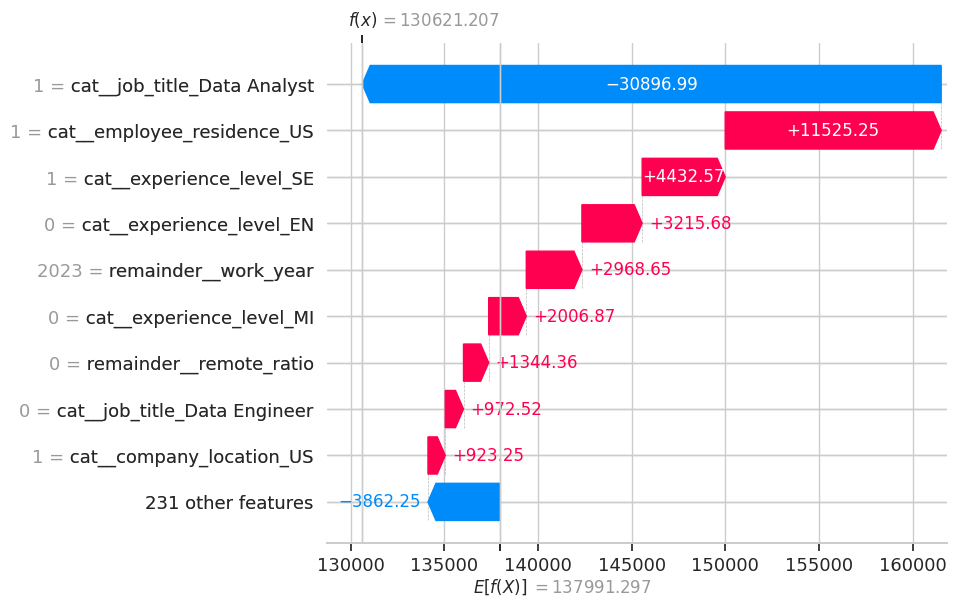

In [29]:
print(f"--- Análisis SHAP para la fila {casos_indices[0]} ---")
print(f"Sueldo Real: ${y_test_c.loc[casos_indices[0]]:,.2f} | Predicción: ${model_clean.predict(casos_x.iloc[[0]])[0]:,.2f}")
shap.plots.waterfall(shap_values[0])

**Conclusión para el Caso 1288:**
Al observar el desglose de SHAP, encontramos el "culpable" del enorme error de predicción. Esta persona tiene un sueldo real excepcionalmente alto ($385k), pero el modelo predijo un valor muchísimo menor (~$130k). ¿Por qué? Principalmente por la variable **`job_title`** (Data Analyst). 

El modelo aprendió a nivel global que el rol de Data Analyst suele estar asociado a bandas salariales más bajas comparado con perfiles ejecutivos o ingenieros. Por lo tanto, al ver ese título, la barra de SHAP nos muestra cómo la regla del `job_title` **tiró fuertemente la predicción hacia abajo**, restándole miles de dólares al sueldo esperado. 

**¿Es coherente con el PFI?** Sí, es totalmente coherente. El PFI (Diagnóstico Global) nos dictó que el rol es uno de los pesos más fuertes para decidir el sueldo. En este caso individual, el modelo aplicó esa misma regla a rajatabla, pero al encontrarse con un *outlier* (un caso atípico de un Data Analyst que cobra muchísimo más que el promedio de sus pares), la regla general falló, generando una subestimación grosera.

## 4.2 Análisis Individual: Caso 3713

--- Análisis SHAP para la fila 3713 ---
Sueldo Real: $120,000.00 | Predicción: $313,212.40


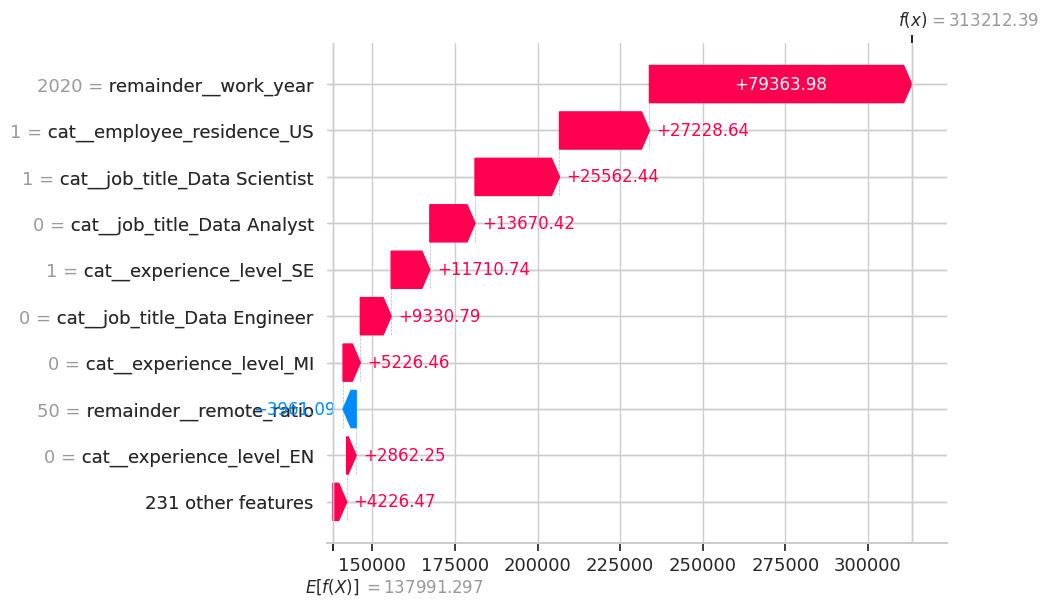

In [30]:
print(f"--- Análisis SHAP para la fila {casos_indices[1]} ---")
print(f"Sueldo Real: ${y_test_c.loc[casos_indices[1]]:,.2f} | Predicción: ${model_clean.predict(casos_x.iloc[[1]])[0]:,.2f}")
shap.plots.waterfall(shap_values[1])

**Conclusión para el Caso 3713:**
En este caso ocurrió el fenómeno exactamente inverso al anterior: el modelo **sobrestimó** violentamente el salario. La persona gana realmente ~$120k, pero el algoritmo predijo un enorme sueldo de ~$313k. 

¿Por qué se infló tanto la predicción? Al mirar las barras del gráfico SHAP, notaremos que variables como su rol o su país lo empujan fuertemente hacia arriba. Sin embargo, **la clave (y la trampa) aquí es temporal**. Tal como agregamos en el análisis exploratorio (EDA), los salarios en Data Science explotaron en 2022 y 2023. Si este empleado pertenece a los registros del año 2020 o 2021, el modelo se confundió severamente: le aplicó una expectativa salarial "actualizada/inflada" a un sueldo viejo.

**¿Es coherente con el análisis general?** Sí. Esto evidencia de forma brillante cómo el modelo aprendió que ciertas combinaciones de país y cargo valen muchísimo dinero (coincidente con el PFI), pero no tuvo la capacidad suficiente para matizar esa regla frente a la variable del tiempo (`work_year`), dejándose engañar por la inflación salarial reciente.